# Affinity Graph Comparison

Compares affinity types for their ability to capture within-cell-type niche structure.
kNN-based methods use **k=35** (~50 µm) for the spatial context and **k=50** for the affinity graph.

| Method | Context | What it encodes |
|---|---|---|
| `arbf_opt` | — | Transcriptomics only (PCA RBF) — baseline |
| `banksy0.5` | mean k=35 | concat(own PCA, mean-neighbour PCA) → RBF |
| `mean_product` | mean k=35 | rbf(own PCA) × rbf(mean-neighbour PCA) |
| `mean_covet_product` | mean+cov k=35 | rbf(own PCA) × rbf(mean PCA) × rbf(COVET) |

`mean_product` vs `banksy0.5`: same two components, product vs concat.  
`mean_covet_product`: 3-way product adding 2nd-moment (COVET) neighbourhood information.

**Metrics** — all affinity-weighted.
- `ct_weighted_purity` — weighted fraction of affinity neighbors sharing the same **cell type**
- `niche_purity_2D` / `niche_purity_3D` — same-cell-type neighbors only, weighted fraction
  sharing the same **niche**, scored against 2D niches (what the affinity was built from)
  and 3D niches (the biologically "true" niches) respectively — see the note below.

## Setup

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!pip install -q scarches SEACells faiss-gpu-cu12 scib-metrics

In [16]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


<Figure size 960x720 with 0 Axes>

## Config — set these for your dataset

In [17]:
import os

DATA_PATH = os.path.join(os.environ['DATA_DIR'], 'spatial/NSCLC_3D_section_28.h5ad')
GRAPH_DIR = os.path.join(os.environ['CODE_DIR'], 'graphs')
DS_NAME   = 'NSCLC_3D_section_28'   # used in affinity filenames
CT_KEY       = 'celltypes'
NICHE_KEY    = 'niches_2D'   # ground truth used to build the affinity (2D section-only neighbors)
NICHE_KEY_3D = 'niches_3D'   # biologically "true" niches (cross-section 3D neighborhoods) — reported alongside as a diagnostic
K_AFF        = 50                       # affinity graph kNN

# Sigma mode for product affinities (mean_product, mean_covet_product): union-graph
# sigma vs per-space sigma gave almost identical metrics; per-space sigma wins
# conceptually (bandwidth estimated from the space that actually produced the
# edge, enforcing AND logic strictly), so it's the only mode used going forward.
PER_SPACE_SIGMA = True

# Set False to drop mean+COVET product from the comparison (e.g. if you don't
# want the extra COVET dependency/compute) while still keeping BANKSY and
# mean product.
INCLUDE_COVET_PRODUCT = True

## Load & preprocess

In [18]:
import scanpy as sc
import numpy as np

ad = sc.read_h5ad(DATA_PATH)
print(ad)
print('obs columns:', ad.obs.columns.tolist())
print('obsm keys:  ', list(ad.obsm.keys()))
print(f'\ncell types ({ad.obs[CT_KEY].nunique()}):', sorted(ad.obs[CT_KEY].unique()))
print(f'niches 2D ({ad.obs[NICHE_KEY].nunique()}):', sorted(ad.obs[NICHE_KEY].dropna().unique()))
print(f'niches 3D ({ad.obs[NICHE_KEY_3D].nunique()}):', sorted(ad.obs[NICHE_KEY_3D].dropna().unique()))

AnnData object with n_obs × n_vars = 58423 × 960
    obs: 'section', 'celltypes', 'niches_3D', 'niches_2D', 'fibroblast_subclusters', 'tumor_pseudotime_rank', 'EMT_niche'
    uns: 'EMT_niche_colors', 'celltypes_colors', 'fibroblast_subclusters_colors', 'log1p', 'niches_2D_colors', 'niches_3D_colors', 'pca'
    obsm: 'X_covet', 'X_pca', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial'
    varm: 'PCs'
    layers: 'SCT', 'counts'
obs columns: ['section', 'celltypes', 'niches_3D', 'niches_2D', 'fibroblast_subclusters', 'tumor_pseudotime_rank', 'EMT_niche']
obsm keys:   ['X_covet', 'X_pca', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial']

cell types (18): ['Alveolar cells', 'B cells', 'Basal epithelial cells', 'Cycling immune cells', 'Cytotoxic T cells', 'Dendritic cells', 'Fibroblasts', 'Lymphatic endothelial cells', 'Macrophages', 'Mast cells', 'Monocytes', 'Pericytes', 'Plasma cells', 'Regulatory T cells', 'Respiratory epith

In [19]:
if 'X_pca' not in ad.obsm:
    sc.pp.highly_variable_genes(ad, n_top_genes=2000)
    sc.tl.pca(ad, n_comps=50, use_highly_variable=True)
    print('PCA computed:', ad.obsm['X_pca'].shape)
else:
    print('X_pca already present:', ad.obsm['X_pca'].shape)

X_pca already present: (58423, 50)


## Generate and save affinity graphs

Each cell runs independently — skip any you've already computed.

In [20]:
from interpretable_ssl.augmenters.graph_generator import generate_affinity, save_affinity

aff_arbf = generate_affinity(ad, k=K_AFF, bk=None, affinity_type='arbf_opt')
aff_arbf.setdiag(0)
aff_arbf.eliminate_zeros()
save_affinity(aff_arbf, DS_NAME, len(ad), affinity_type='arbf_opt',
              k_neighbors=K_AFF, graph_dir=GRAPH_DIR)

arbf_opt
arbf_opt: recalculating PCA (n_comps=50) then optimized rbf ...
[rbf_optimized] n=58423  k=50  build_on=X_pca  graph_construction=union
[rbf_optimized] feature stats: shape=(58423, 50)  min=-1.9677e+01  mean=1.9889e+00  max=3.2125e+01  std=3.0460e+00
[rbf_optimized] step 1-4: kNN → sigma → sym ...
[rbf_optimized] sym nnz=4700191  nnz/row=80.5  sigma min=6.4085e+00  mean=1.4497e+01  max=2.0480e+01
[rbf_optimized] step 5: computing RBF ...
[rbf_optimized] done  M.nnz=4700191  rbf min=7.9388e-02  mean=3.4309e-01  max=1.0000e+00
Saved: /content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_arbf_opt.pkl


'/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_arbf_opt.pkl'

In [21]:
aff_banksy = generate_affinity(ad, k=K_AFF, bk=None, affinity_type='banksy0.5')
aff_banksy.setdiag(0)
aff_banksy.eliminate_zeros()
save_affinity(aff_banksy, DS_NAME, len(ad), affinity_type='banksy0.5',
              k_neighbors=K_AFF, graph_dir=GRAPH_DIR)

banksy0.5
banksy: alpha=0.50  V_pca=463.919  V_ctx=116.121  lambda=0.894  weighted_context=False
  [build_seacell_kernel] n=58423  k=50  x_graph.shape=(58423, 100)  X_aff.shape=(58423, 100)  symmetrize=False
  [build_seacell_kernel] kNN done in 46.2s  idxs.shape=(58423, 50)  (self excluded)
  [build_seacell_kernel] RBF done in 1.6s  A_vals min=0.1306  max=0.8568  mean=0.3598
  [build_seacell_kernel] sparse matrix built  nnz=2921150  nnz_per_row=50.0
Saved: /content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_banksy0.5.pkl


'/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_banksy0.5.pkl'

In [22]:
from interpretable_ssl.augmenters.graph_generator import generate_affinity, save_affinity

In [23]:
aff = generate_affinity(ad, k=K_AFF, bk=None, affinity_type='mean_product',
                        per_space_sigma=PER_SPACE_SIGMA)
aff.setdiag(0)
aff.eliminate_zeros()
save_affinity(aff, DS_NAME, len(ad), affinity_type='mean_product',
              k_neighbors=K_AFF, graph_dir=GRAPH_DIR)

mean_product
[generate_affinity] mean_product: feature_k=35  aff_k=50  weight=rbf_pca×rbf_mean_pca  per_space_sigma=True  weighted_context=False
compute_mean_pca_context: k=35  dims=50  V=116.121  mode=plain avg
[rbf_product] n=58423  k=50  spaces=['X_pca', 'X_mean_pca']
[rbf_product] step 1.1: kNN → sym  X_pca  (sc.pp.neighbors) ...
[rbf_product] step 1.1 done (35.7s)  nnz=4700191  nnz/row=80.5
[rbf_product] step 1.2: kNN → sym  X_mean_pca  (sc.pp.neighbors) ...
[rbf_product] step 1.2 done (30.9s)  nnz=3731491  nnz/row=63.9
[rbf_product] step 2: union done (0.3s)  nnz=8303655  nnz/row=142.1
[rbf_product] step 3: RBF product over 2 spaces  sigma=per-space (own kNN) ...
[rbf_product]   X_pca: sigma [6.408e+00, 1.450e+01, 2.048e+01]
[rbf_product]   X_mean_pca: sigma [1.171e+00, 3.785e+00, 6.187e+00]
[rbf_product] step 3 done (13.7s)  nnz=8303655
[rbf_product] step 4: top-50 pruning per row + re-symmetrize ...
[rbf_product] step 4 done (0.8s)  nnz=3414094 (was 8303655, 59% removed)  nnz/r

'/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_mean_product.pkl'

In [24]:
if INCLUDE_COVET_PRODUCT:
    aff = generate_affinity(ad, k=K_AFF, bk=None, affinity_type='mean_covet_product',
                            per_space_sigma=PER_SPACE_SIGMA)
    aff.setdiag(0)
    aff.eliminate_zeros()
    save_affinity(aff, DS_NAME, len(ad), affinity_type='mean_covet_product',
                  k_neighbors=K_AFF, graph_dir=GRAPH_DIR)

mean_covet_product
[generate_affinity] mean_covet_product: feature_k=35  n_pcs=10  aff_k=50  weight=rbf_pca×rbf_mean_pca×rbf_covet  per_space_sigma=True  weighted_context=False
compute_mean_pca_context: k=35  dims=50  V=116.121  mode=plain avg
covet: k=35  n_pcs=10  n_comps=50  alpha=1.0 (covet-only)  cov_dims=55→50
[rbf_product] n=58423  k=50  spaces=['X_pca', 'X_mean_pca', 'X_covet']
[rbf_product] step 1.1: kNN → sym  X_pca  (sc.pp.neighbors) ...
[rbf_product] step 1.1 done (32.5s)  nnz=4700191  nnz/row=80.5
[rbf_product] step 1.2: kNN → sym  X_mean_pca  (sc.pp.neighbors) ...
[rbf_product] step 1.2 done (28.2s)  nnz=3731491  nnz/row=63.9
[rbf_product] step 1.3: kNN → sym  X_covet  (sc.pp.neighbors) ...
[rbf_product] step 1.3 done (30.1s)  nnz=4131321  nnz/row=70.7
[rbf_product] step 2: union done (0.3s)  nnz=11376151  nnz/row=194.7
[rbf_product] step 3: RBF product over 3 spaces  sigma=per-space (own kNN) ...
[rbf_product]   X_pca: sigma [6.408e+00, 1.450e+01, 2.048e+01]
[rbf_product

## Compute affinity metrics

Load saved affinities (or reuse in-memory ones if they're still in scope).

In [25]:
import pickle, os
from interpretable_ssl.configs.paths import get_affinity_path

def load_aff(affinity_type):
    path = get_affinity_path(DS_NAME, len(ad), k_neighbors=K_AFF,
                             affinity_type=affinity_type, graph_dir=GRAPH_DIR)
    with open(path, 'rb') as f:
        return pickle.load(f)

affinities = {
    'PCA only'     : load_aff('arbf_opt'),
    'BANKSY'       : load_aff('banksy0.5'),
    'mean product' : load_aff('mean_product'),
}
if INCLUDE_COVET_PRODUCT:
    affinities['mean+COVET product'] = load_aff('mean_covet_product')

Two ground truths are scored against the same affinity graphs:
- **2D niches** — what the affinity was actually built from (single-section
  neighbors only). This is the fair, apples-to-apples score of "does the
  affinity capture the structure it had access to."
- **3D niches** — the biologically "true" niches (cross-section 50µm
  neighborhoods, per the source paper). The affinity never sees 3D spatial
  info, so this is a diagnostic: does *gene expression* (own PCA, and
  neighbor mean-PCA/COVET) leak any signal about the 3D niche a cell
  actually lives in, beyond what 2D geometry alone would predict?

`ct_weighted_purity` doesn't depend on niche labels, so it's computed once.
The 2D→3D **gap** per method tells you how much of that method's apparent
niche-purity is actually 3D-biology-general vs 2D-geometry-specific.

In [26]:
import pandas as pd
from interpretable_ssl.evaluation.metric_helpers.affinity_metrics import (
    weighted_purity, weighted_purity_within_group,
)

ct_labels       = ad.obs[CT_KEY].astype(str).values
niche_labels_2d = ad.obs[NICHE_KEY].astype(str).replace('nan', 'Unknown').values
niche_labels_3d = ad.obs[NICHE_KEY_3D].astype(str).replace('nan', 'Unknown').values

rows = []
for method, aff in affinities.items():
    ct_pur = float(np.nanmean(weighted_purity(aff, ct_labels)))
    pur_2d = float(np.nanmean(weighted_purity_within_group(aff, ct_labels, niche_labels_2d)))
    pur_3d = float(np.nanmean(weighted_purity_within_group(aff, ct_labels, niche_labels_3d)))
    rows.append({
        'method': method,
        'ct_weighted_purity': ct_pur,
        'niche_purity_2D': pur_2d,
        'niche_purity_3D': pur_3d,
        'gap_2D_minus_3D': pur_2d - pur_3d,
    })

results = pd.DataFrame(rows).set_index('method')
results_styled = (
    results.round(4)
    .style.set_caption('Affinity metrics — cell-type purity, and within-CT niche purity scored against both 2D and 3D ground truth')
    .background_gradient(subset=['niche_purity_2D', 'niche_purity_3D'], cmap='YlGn', vmin=0, vmax=1)
    .background_gradient(subset=['gap_2D_minus_3D'], cmap='Reds', vmin=0)
)
results_styled

,ct_weighted_purity,niche_purity_2D,niche_purity_3D,gap_2D_minus_3D
method,,,,
PCA only,0.765600,0.359500,0.351500,0.008000
BANKSY,0.743900,0.606800,0.585100,0.021700
mean product,0.599000,0.716300,0.709500,0.006800
mean+COVET product,0.570400,0.772200,0.774200,-0.002000


## Visualize

### Trade-off scatter (hero figure)

x = cell-type weighted purity, y = within-CT niche weighted purity.
Each method gets **two** markers — a circle (2D ground truth) and a
triangle (3D ground truth), joined by a dotted line. A short/vertical line
means the method's niche signal generalizes to the biological 3D niches;
a long line means it's mostly fitting 2D-specific geometry.
Top-right corner = best of both worlds.

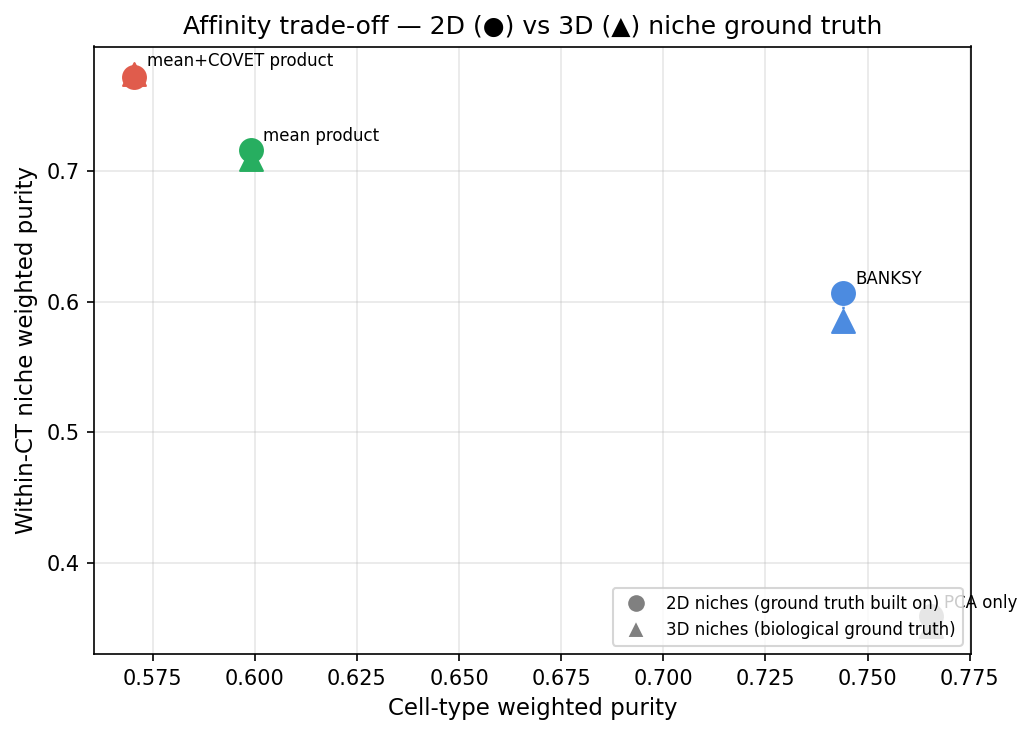

In [27]:
import matplotlib.pyplot as plt

colors = {
    'PCA only'           : '#888888',
    'BANKSY'             : '#4C8BE0',
    'mean product'       : '#27AE60',
    'mean+COVET product' : '#E05C4C',
}

fig, ax = plt.subplots(figsize=(7, 5))
for method, row in results.iterrows():
    c = colors.get(method, 'black')
    x = row['ct_weighted_purity']
    y2d, y3d = row['niche_purity_2D'], row['niche_purity_3D']
    ax.plot([x, x], [y2d, y3d], color=c, linestyle=':', linewidth=1.2, zorder=2)
    ax.scatter(x, y2d, color=c, marker='o', s=120, zorder=3, label=f'{method} (2D)')
    ax.scatter(x, y3d, color=c, marker='^', s=120, zorder=3, label=f'{method} (3D)')
    ax.annotate(method, (x, max(y2d, y3d)), textcoords='offset points',
                xytext=(6, 4), fontsize=8)

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=9, label='2D niches (ground truth built on)'),
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=9, label='3D niches (biological ground truth)'),
]
ax.set_xlabel('Cell-type weighted purity', fontsize=11)
ax.set_ylabel('Within-CT niche weighted purity', fontsize=11)
ax.set_title('Affinity trade-off — 2D (●) vs 3D (▲) niche ground truth', fontsize=12)
ax.legend(handles=handles, fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'affinity_tradeoff.pdf'), bbox_inches='tight')
plt.show()

### Bar charts

Left: cell-type purity (niche-label-independent, one bar per method).
Middle: within-CT niche purity, 2D vs 3D ground truth side by side.
Right: the 2D−3D gap — how much of the niche score is 2D-geometry-specific
vs biologically general.

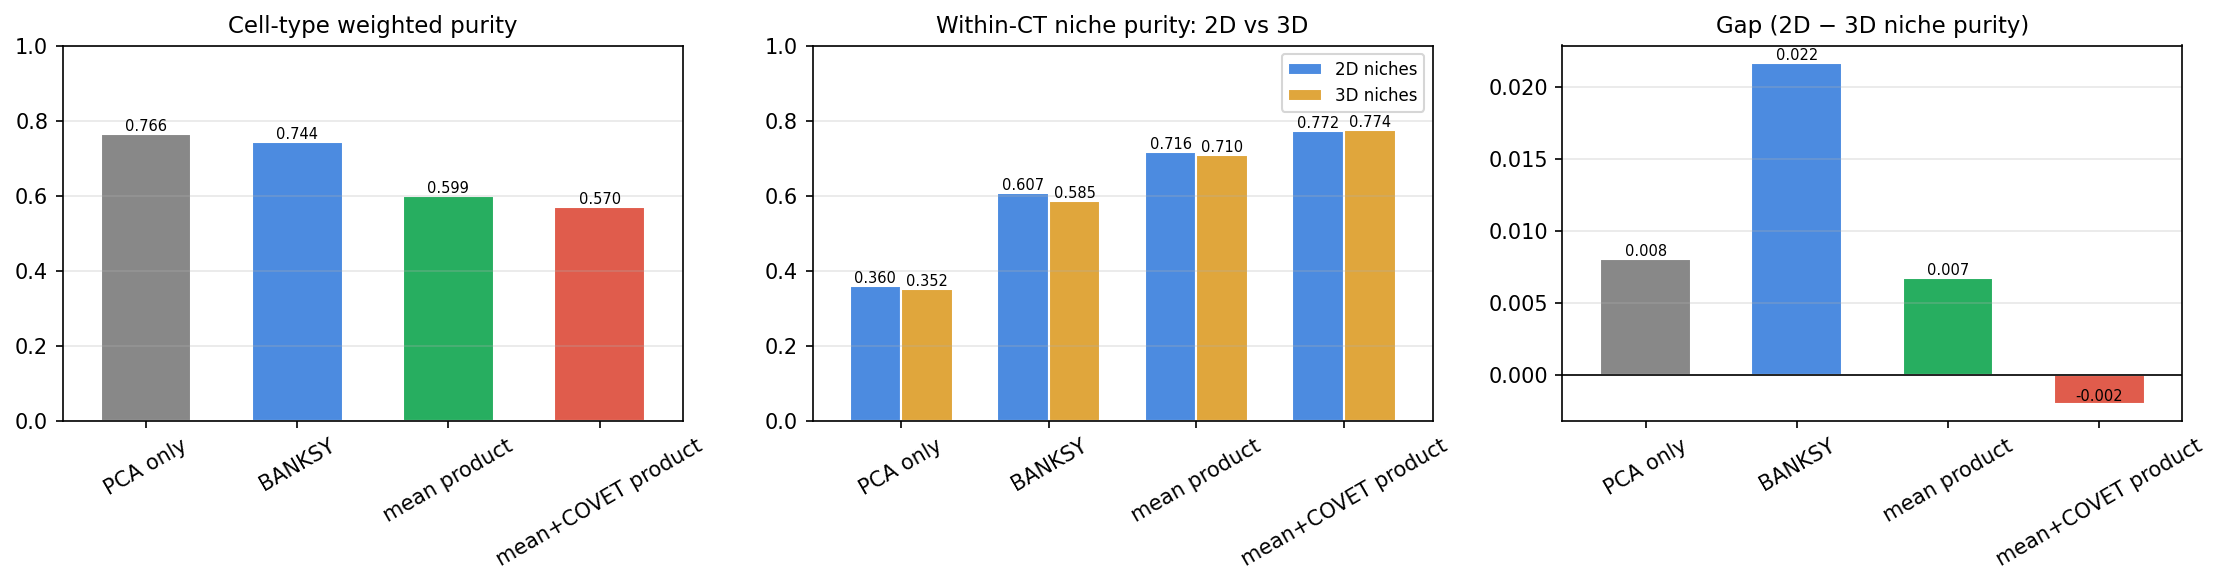

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: cell-type purity
bar_colors = [colors.get(m, 'steelblue') for m in results.index]
results['ct_weighted_purity'].plot(kind='bar', ax=axes[0], color=bar_colors, edgecolor='white', width=0.6)
axes[0].set_title('Cell-type weighted purity', fontsize=11)

# Panel 2: 2D vs 3D niche purity, grouped
results[['niche_purity_2D', 'niche_purity_3D']].plot(
    kind='bar', ax=axes[1], color=['#4C8BE0', '#E0A63C'], edgecolor='white', width=0.7,
)
axes[1].set_title('Within-CT niche purity: 2D vs 3D', fontsize=11)
axes[1].legend(['2D niches', '3D niches'], fontsize=8)

# Panel 3: the gap
results['gap_2D_minus_3D'].plot(kind='bar', ax=axes[2], color=bar_colors, edgecolor='white', width=0.6)
axes[2].set_title('Gap (2D − 3D niche purity)', fontsize=11)
axes[2].axhline(0, color='black', linewidth=0.8)

for ax, ylim in zip(axes, [(0, 1), (0, 1), None]):
    ax.set_xlabel('')
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'affinity_bars.pdf'), bbox_inches='tight')
plt.show()

### UMAP of each affinity graph

Colored by cell type and by niche. UMAP is computed directly from each affinity
graph in `affinities` (the same four methods scored in the metrics table above),
so this is an apples-to-apples view of what structure each affinity "sees" —
not a stand-in built from the raw feature spaces.

In [29]:
import scanpy as sc

def umap_from_affinity(ad, aff, key, n_neighbors=K_AFF):
    """Run UMAP directly on a precomputed affinity graph (used as connectivities)."""
    conn_key = f'{key}_connectivities'
    neighbors_key = f'{key}_neighbors'
    ad.obsp[conn_key] = aff.tocsr()
    ad.uns[neighbors_key] = {
        'connectivities_key': conn_key,
        'distances_key': conn_key,  # unused by tl.umap, only needs to exist
        'params': {'n_neighbors': n_neighbors, 'method': 'umap'},
    }
    sc.tl.umap(ad, neighbors_key=neighbors_key)
    return ad.obsm['X_umap'].copy()

umaps = {name: umap_from_affinity(ad, aff, name.replace(' ', '_').replace('+', ''))
         for name, aff in affinities.items()}

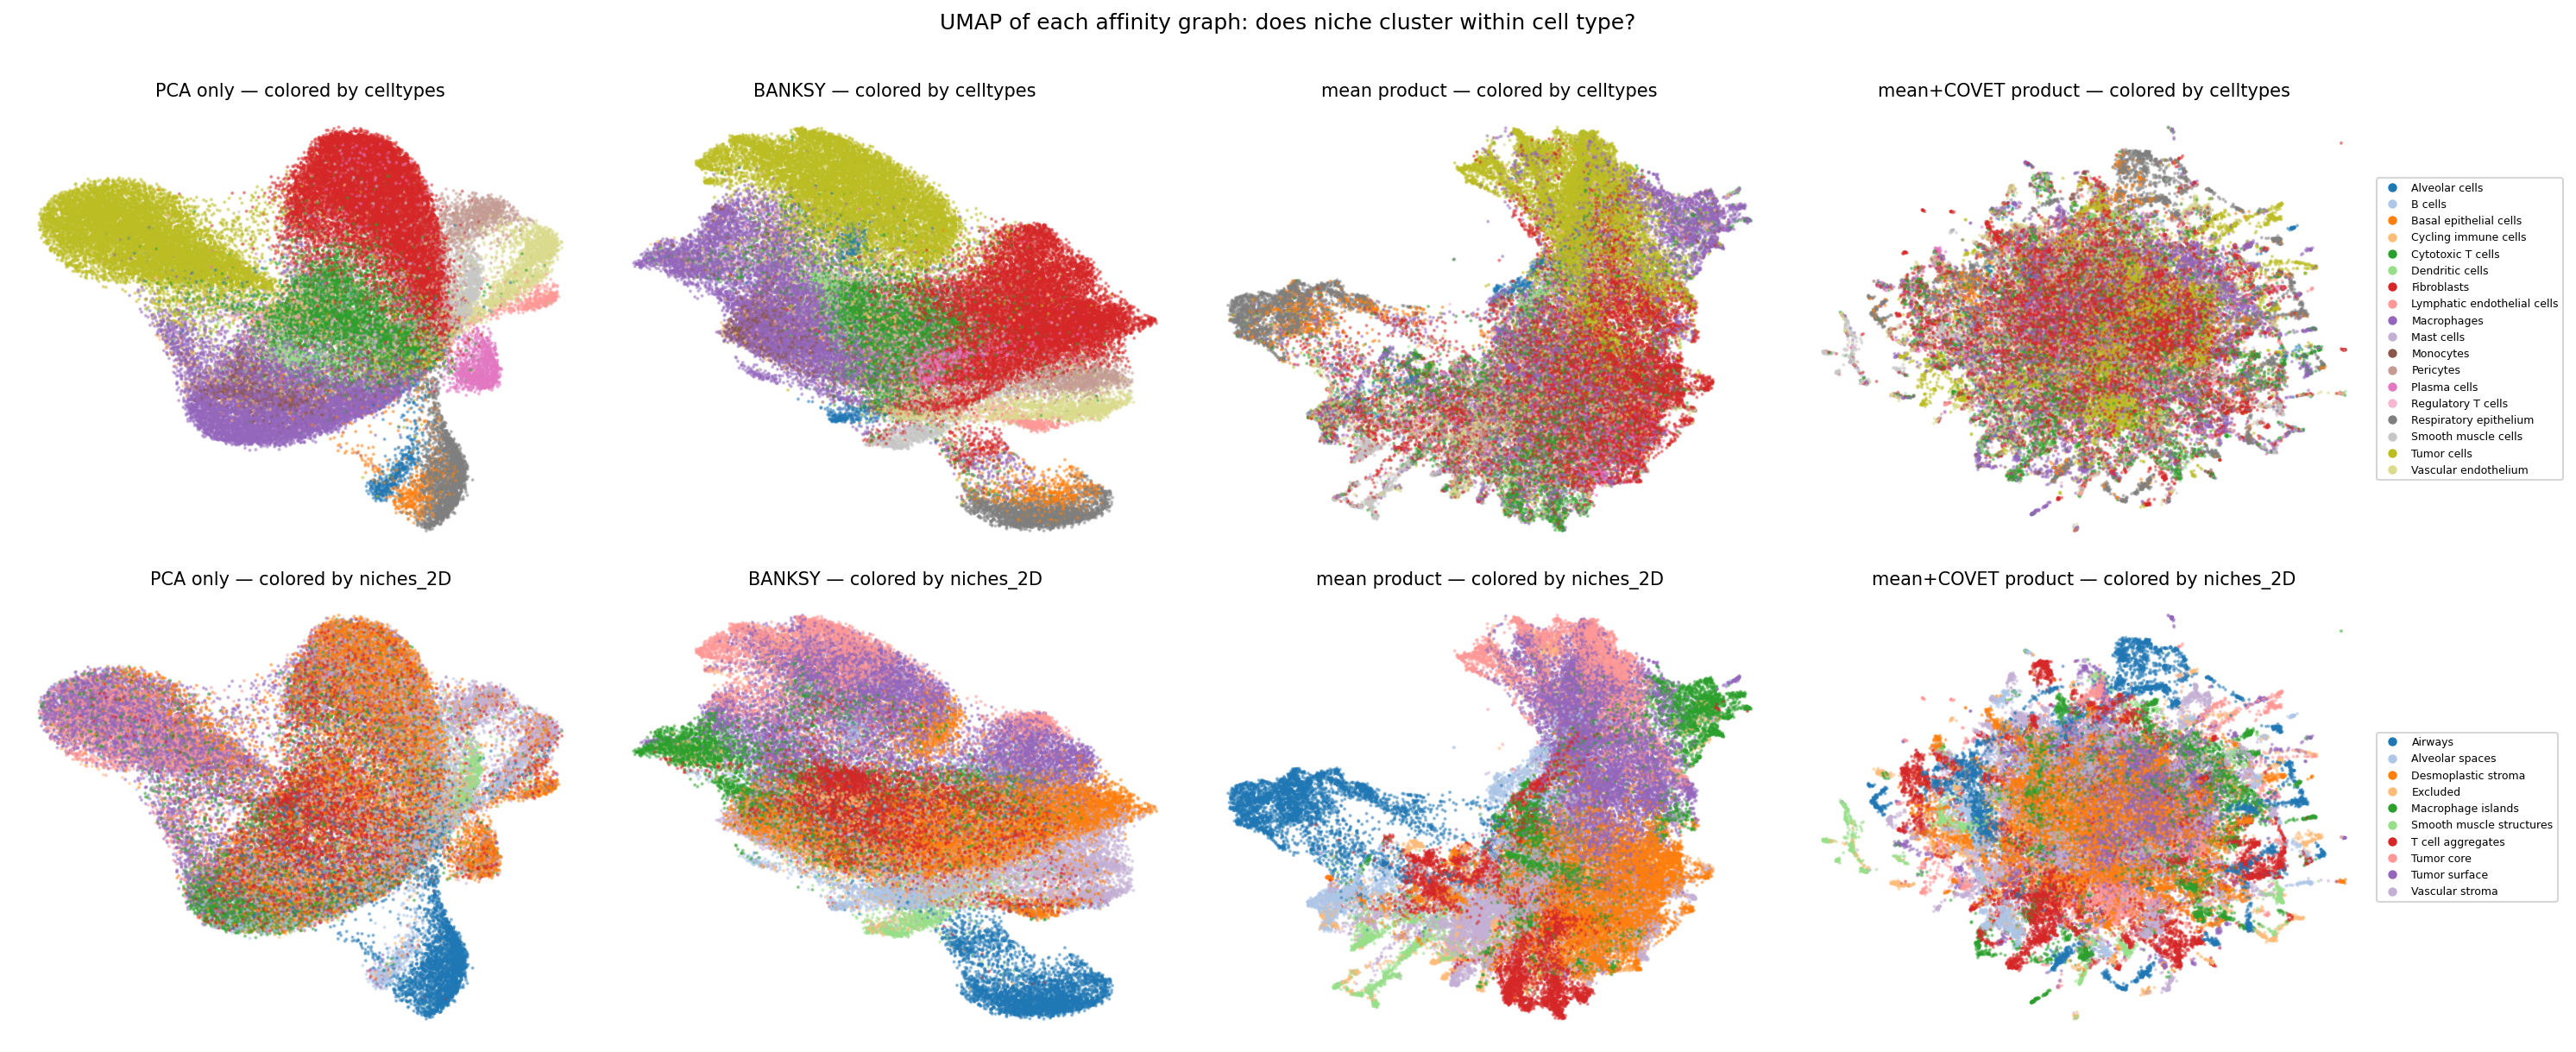

In [30]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

color_keys = [CT_KEY, NICHE_KEY]
method_labels = list(affinities.keys())
n_rows = len(color_keys)
n_cols = len(method_labels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

for row_i, ck in enumerate(color_keys):
    categories = ad.obs[ck].astype('category').cat.categories
    palette = plt.cm.tab20.colors
    color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(categories)}
    cell_colors = [color_map[c] for c in ad.obs[ck].astype(str)]

    for col_i, method in enumerate(method_labels):
        ax = axes[row_i][col_i]
        X_umap = umaps[method]
        ax.scatter(X_umap[:, 0], X_umap[:, 1],
                   c=cell_colors, s=1, alpha=0.4, rasterized=True)
        ax.set_title(f'{method} — colored by {ck}', fontsize=10)
        ax.axis('off')

    handles = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[c], markersize=6, label=c)
               for c in categories]
    axes[row_i][-1].legend(handles=handles, fontsize=6,
                            loc='center left', bbox_to_anchor=(1, 0.5),
                            ncol=max(1, len(categories) // 20))

plt.suptitle('UMAP of each affinity graph: does niche cluster within cell type?', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'affinity_umap_comparison.pdf'),
            bbox_inches='tight', dpi=150)
plt.show()

### Per-cell-type breakdown

Which cell types benefit most from niche-aware affinity — and does that
benefit hold up against the 3D ground truth, or is it 2D-geometry-specific?
Two heatmaps side by side, same color scale, same row order (sorted by the
2D score) so they're directly comparable.

In [31]:
def per_ct_purity(niche_labels):
    per_ct = {}
    for method, aff in affinities.items():
        per_cell = weighted_purity_within_group(aff, ct_labels, niche_labels)
        df = ad.obs[[CT_KEY]].copy()
        df['niche_purity'] = per_cell
        per_ct[method] = df.groupby(CT_KEY)['niche_purity'].mean()
    return pd.DataFrame(per_ct)

per_ct_2d = per_ct_purity(niche_labels_2d)
per_ct_3d = per_ct_purity(niche_labels_3d)

sort_col = list(affinities.keys())[-1]  # last (best-performing) method, whichever is present
row_order = per_ct_2d.sort_values(sort_col, ascending=False).index
per_ct_2d = per_ct_2d.loc[row_order]
per_ct_3d = per_ct_3d.loc[row_order]

print('--- 2D niche purity by cell type ---')
print(per_ct_2d.round(3))
print('\n--- 3D niche purity by cell type ---')
print(per_ct_3d.round(3))

--- 2D niche purity by cell type ---
                             PCA only  BANKSY  mean product  \
celltypes                                                     
Respiratory epithelium          0.962   0.985         0.992   
Basal epithelial cells          0.918   0.978         0.984   
Pericytes                       0.519   0.697         0.801   
Dendritic cells                 0.361   0.640         0.792   
Vascular endothelium            0.408   0.630         0.764   
Smooth muscle cells             0.436   0.651         0.774   
Alveolar cells                  0.597   0.699         0.765   
Lymphatic endothelial cells     0.412   0.579         0.734   
Mast cells                      0.213   0.538         0.692   
Cytotoxic T cells               0.273   0.557         0.716   
Plasma cells                    0.395   0.579         0.701   
Macrophages                     0.247   0.554         0.699   
Tumor cells                     0.413   0.640         0.701   
Fibroblasts       

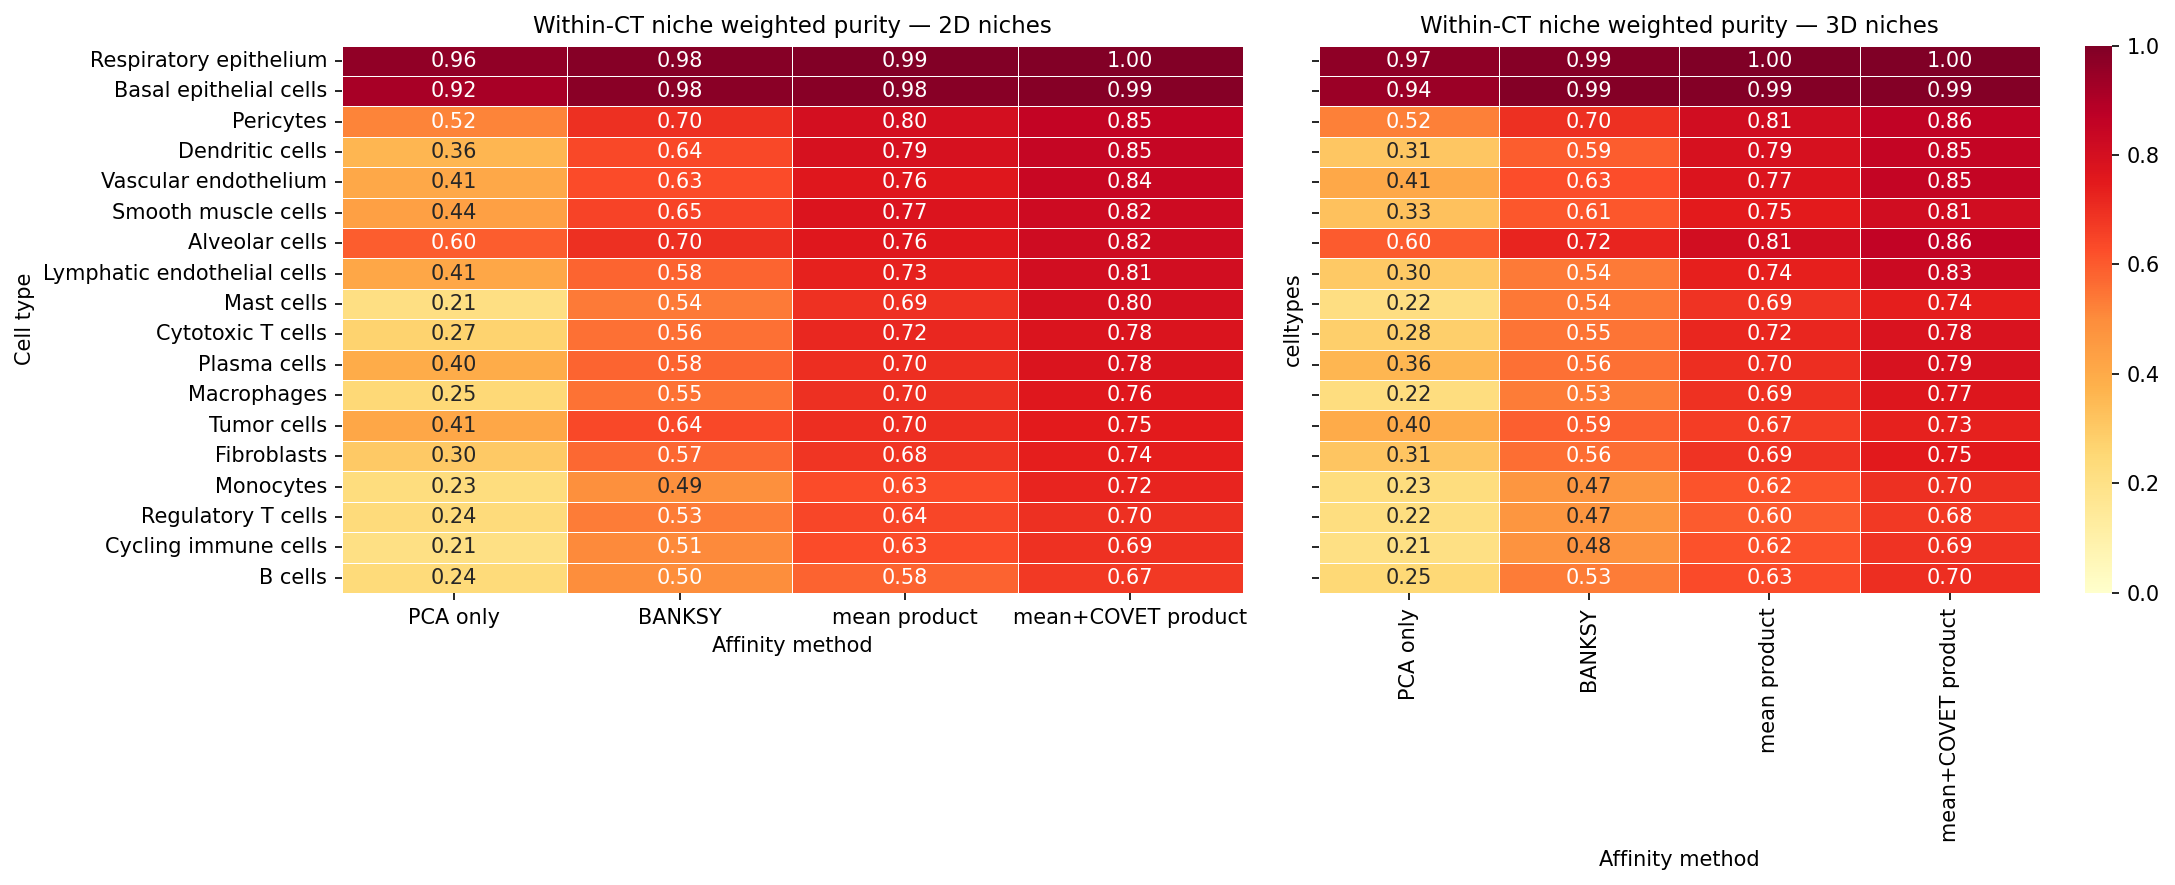

In [32]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, df, title in zip(axes, [per_ct_2d, per_ct_3d], ['2D niches', '3D niches']):
    sns.heatmap(
        df, annot=True, fmt='.2f', cmap='YlOrRd',
        vmin=0, vmax=1, ax=ax, linewidths=0.4, cbar=ax is axes[-1],
    )
    ax.set_title(f'Within-CT niche weighted purity — {title}', fontsize=11)
    ax.set_xlabel('Affinity method')
axes[0].set_ylabel('Cell type')
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'affinity_per_ct_heatmap.pdf'), bbox_inches='tight')
plt.show()